In [110]:
# Pacotes
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [111]:
# Carregar a área de estudo
path_json = "../data/bacias_meso_SF.geojson"
area = gpd.read_file(path_json)

In [ ]:
# Carregar dataset com os índices de desertificação
ds = xr.open_dataset('../data/indices_desertificacao_anual.nc', engine='netcdf4')
ds

<xarray.Dataset> Size: 121MB
Dimensions:     (year: 26, y: 467, x: 340)
Coordinates:
  * year        (year) int64 208B 2000 2001 2002 2003 ... 2022 2023 2024 2025
  * y           (y) float64 4kB -8.312 -8.318 -8.322 ... -10.63 -10.64 -10.64
  * x           (x) float64 3kB -38.0 -37.99 -37.99 ... -36.31 -36.31 -36.3
Data variables:
    MSAVI_max   (year, y, x) float32 17MB ...
    Albedo_min  (year, y, x) float32 17MB ...
    M_norm      (year, y, x) float32 17MB ...
    A_norm      (year, y, x) float32 17MB ...
    DDI         (y, x, year) float64 33MB ...
    SASDI       (year, y, x) float32 17MB ...
    k_slope     (y, x) float64 1MB ...
    r2          (y, x) float64 1MB ...
    p_value     (y, x) float64 1MB ...
    alpha       (y, x) float64 1MB ...

In [ ]:
ddi = ds['DDI']
media = ddi.mean(skipna=True)
desvio = ddi.std(skipna=True)

# Criar classes em uma matriz vazia
classes_ddi = xr.full_like(ddi, np.nan)

# 3. Aplicar os limiares estatísticos através de máscaras aninhadas:
# Classe 1: Extrema
classes_ddi = xr.where(ddi < (media - 1.5 * desvio), 1, classes_ddi)

# Classe 2: Severa
classes_ddi = xr.where((ddi >= (media - 1.5 * desvio)) & (ddi < (media - 0.5 * desvio)), 2, classes_ddi)

# Classe 3: Moderada
classes_ddi = xr.where((ddi >= (media - 0.5 * desvio)) & (ddi < (media + 0.5 * desvio)), 3, classes_ddi)

# Classe 4: Leve
classes_ddi = xr.where((ddi >= (media + 0.5 * desvio)) & (ddi < (media + 1.5 * desvio)), 4, classes_ddi)

# Classe 5: Não Desertificada
classes_ddi = xr.where(ddi >= (media + 1.5 * desvio), 5, classes_ddi)

# 4. Inserir a nova variável no Dataset
ds['DDI_Classes'] = classes_ddi




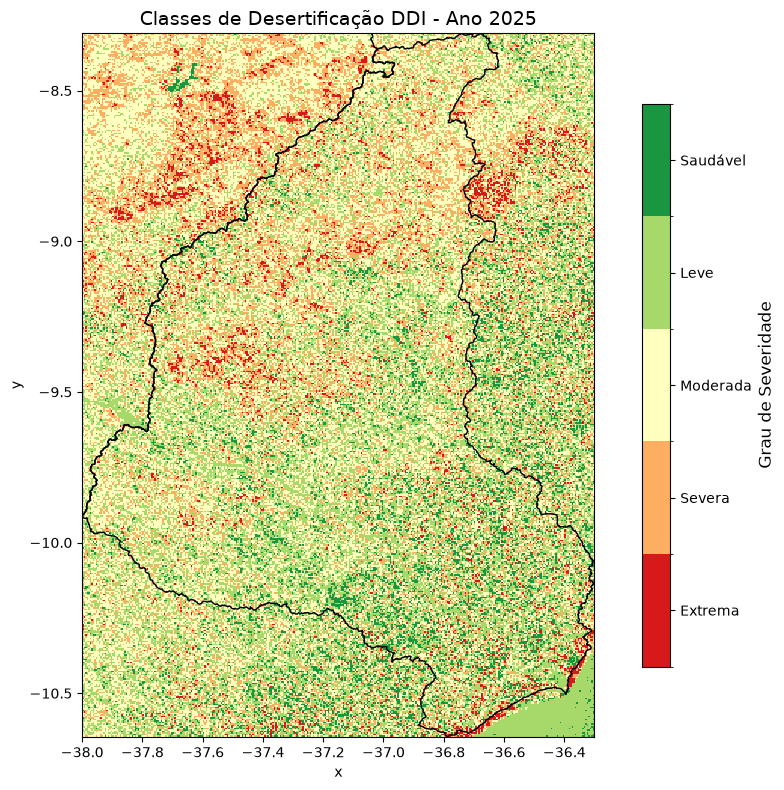

In [118]:
# Definir as 5 cores: Vermelho, Laranja, Amarelo, Verde claro, Verde escuro
cores_classes = ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
mapa_cores = ListedColormap(cores_classes)

# Rótulos para a legenda
nomes_classes = ['Extrema', 'Severa', 'Moderada', 'Leve', 'Saudável']

# Definir o ano
ano = 2025

# Plotar o mapa de um ano específico (ex: 2023)
fig, ax = plt.subplots(figsize=(10, 8))

# O argumento 'levels' centraliza a cor nos números inteiros que definimos (1 a 5)
plot = ds['DDI_Classes'].sel(year=ano).plot(
    ax=ax,
    cmap=mapa_cores,
    levels=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    add_colorbar=False # Desligamos a original para customizar a nossa
)

# Plotar area de estudo em cima
area.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

# Customizar a barra de legendas
cbar = plt.colorbar(plot, ax=ax, ticks=[1, 2, 3, 4, 5], orientation='vertical', shrink=0.8)
cbar.ax.set_yticklabels(nomes_classes)
cbar.set_label('Grau de Severidade', fontsize=12)

ax.set_title(f'Classes de Desertificação DDI - Ano {ano}', fontsize=14)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [119]:
# Vou salvar um .tif para eu abrir no qgis e ver se está tudo certo
ds['DDI_Classes'].sel(year=ano).rio.to_raster(f'../data/DDI_Classes_{ano}.tif')

In [58]:
# ---------------------------------------------------------
# Classificação Final de Susceptibilidade (Exemplo baseado no SASDI)
# Dividindo quantitativamente o cenário em 4 níveis via xr.where otimizado
# (Os limiares exatos devem ser ajustados via validação em campo / SVM / Random Forest)
# ---------------------------------------------------------
classificacao = xr.full_like(ds['SASDI'], fill_value=np.nan)
# Supondo thresholds hipotéticos de distância no espaço de recursos:
classificacao = xr.where(ds['SASDI'] < 0.4, 1, classificacao) # 1: Não-desertificado (Próximo à origem 1,0)
classificacao = xr.where((ds['SASDI'] >= 0.4) & (ds['SASDI'] < 0.7), 2, classificacao) # 2: Leve
classificacao = xr.where((ds['SASDI'] >= 0.7) & (ds['SASDI'] < 0.9), 3, classificacao) # 3: Severa
classificacao = xr.where(ds['SASDI'] >= 0.9, 4, classificacao) # 4: Extrema (Perto de 0 MSAVI e Alto Albedo)


(np.float64(-0.5), np.float64(1262.5), np.float64(1531.5), np.float64(-0.5))

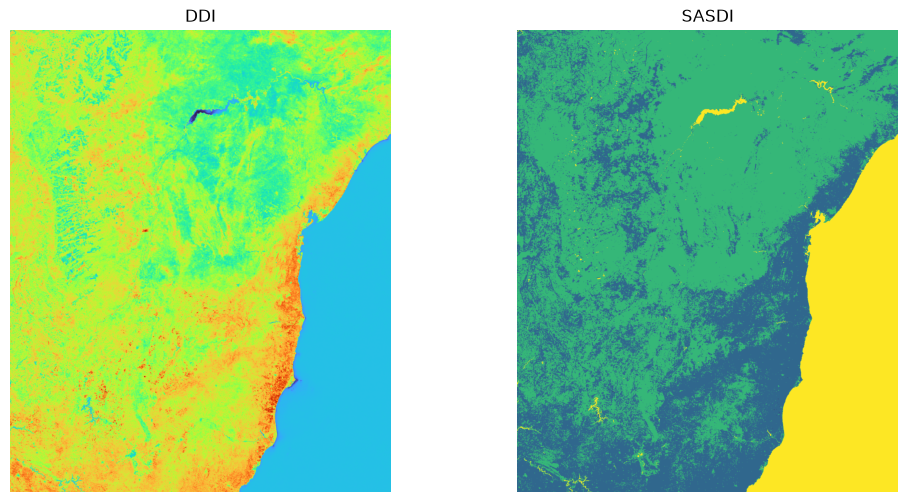

In [79]:
import cartopy.crs as ccrs

# Plotar MSAVI e ALBEDO Lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Colocar a ultima imagem (2025) para visualização
ax[0].imshow(ds['DDI'].isel(time=25), cmap='turbo')
ax[0].set_title('DDI')
ax[0].axis('off')
# Adicionar uma cor que represente melhor a classificação de degradação/desertificação  # Verde, Amarelo, Laranja, Vermelho
ax[1].imshow(classificacao.isel(time=25))
ax[1].set_title('SASDI')
ax[1].axis('off')


 eemont,  getTimeSeriesByRegion,  UltraPlot 

In [91]:
ds_2025.rio.resolution()[0]

0.008983152841195214

In [ ]:
import xarray as xr


<module 'xarray' from '/var/data/python/lib/python3.13/site-packages/xarray/__init__.py'>

In [102]:
ds = xr.open_dataset('output.nc', engine='netcdf4')
ds

<xarray.Dataset> Size: 640kB
Dimensions:  (y: 234, x: 170)
Coordinates:
  * y        (y) float64 2kB -8.315 -8.325 -8.335 ... -10.63 -10.64 -10.65
  * x        (x) float64 1kB -37.99 -37.98 -37.97 -37.96 ... -36.32 -36.31 -36.3
Data variables:
    MSAVI    (y, x) float32 159kB ...
    Albedo   (y, x) float32 159kB ...
    DDI      (y, x) float32 159kB ...
    SASDI    (y, x) float32 159kB ...

In [86]:
# 1. Seleciona a imagem do ano de 2025 (índice 25 ou via .sel(time='2025'))
ds_2025 = classificacao.isel(time=25)

# 2. Calcula a área do pixel em m² a partir da resolução da grade
# Por exemplo: (1000m x 1000m) = 1.000.000 m² por pixel
res_x, res_y = abs(1000), abs(1000)
area_pixel_m2 = res_x * res_y

# 3. Dicionário para armazenar em km² e hectares
area_km2 = {}
area_ha = {}
num_pixels = {}

for classe in [1, 2, 3, 4]:
    # Conta a quantidade de pixels da classe
    count = int(np.sum(ds_2025 == classe).values)
    
    num_pixels[classe] = count
    area_km2[classe] = (count * area_pixel_m2) / 1_000_000  # 1 km² = 1.000.000 m²
    area_ha[classe] = (count * area_pixel_m2) / 10_000       # 1 ha = 10.000 m²

# 4. Organizar em um DataFrame legível
df_area = pd.DataFrame({
    'Classe': [1, 2, 3, 4],
    'Pixels': [num_pixels[c] for c in [1, 2, 3, 4]],
    'Área (km²)': [round(area_km2[c], 2) for c in [1, 2, 3, 4]],
    'Área (ha)': [round(area_ha[c], 2) for c in [1, 2, 3, 4]]
})

print(df_area)

   Classe   Pixels  Área (km²)    Área (ha)
0       1       39        39.0       3900.0
1       2   563776    563776.0   56377600.0
2       3  1018317   1018317.0  101831700.0
3       4   352784    352784.0   35278400.0
